In [1]:
import pandas as pd

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
file_path = '/content/drive/MyDrive/Junior-Data-Analyst/Reports/Week9/Jumat/Online Retail.xlsx'
df = pd.read_excel(file_path)
display(df.tail())

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [7]:
num_countries = df['Country'].nunique()
print(f"There are {num_countries} unique countries in the dataset.")

There are 38 unique countries in the dataset.


In [9]:
# Hal-hal yang perlu dicek/dibersihkan:
print(df.isna().sum())  # CustomerID sering banyak yang kosong (~25%)
print((df['Quantity'] < 0).sum())  # Quantity negatif = retur/pembatalan
print(df['InvoiceNo'].astype(str).str.startswith('C').sum())  # InvoiceNo mulai huruf 'C' = cancellation


InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64
10624
9288


In [10]:
# Ensure InvoiceDate is in datetime format
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Calculate Total Sales for each transaction
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# Extract month from InvoiceDate
df['Month'] = df['InvoiceDate'].dt.to_period('M')

# Group by month and sum the TotalPrice
monthly_sales = df.groupby('Month')['TotalPrice'].sum().reset_index()

# Find the month with the lowest sales
lowest_sales_month = monthly_sales.loc[monthly_sales['TotalPrice'].idxmin()]

print("Monthly Sales:")
display(monthly_sales)

print(f"\nMonth with the Lowest Sales: {lowest_sales_month['Month']} with total sales of {lowest_sales_month['TotalPrice']:.2f}")

Monthly Sales:


,Month,TotalPrice
0,2010-12,748957.020
1,2011-01,560000.260
2,2011-02,498062.650
3,2011-03,683267.080
4,2011-04,493207.121
5,2011-05,723333.510
6,2011-06,691123.120
7,2011-07,681300.111
8,2011-08,682680.510
9,2011-09,1019687.622



Month with the Lowest Sales: 2011-12 with total sales of 433668.01


/tmp/ipykernel_817/761731936.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Month_str', y='TotalPrice', data=monthly_sales, palette='viridis')


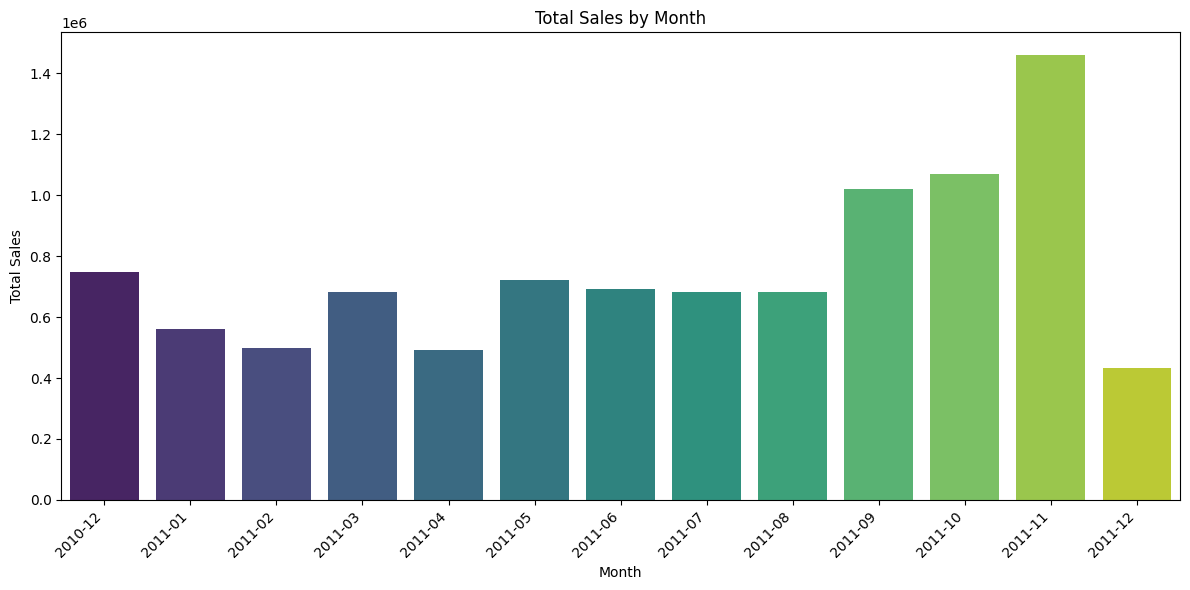

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert 'Month' to string for better plotting on x-axis
monthly_sales['Month_str'] = monthly_sales['Month'].astype(str)

plt.figure(figsize=(12, 6))
sns.barplot(x='Month_str', y='TotalPrice', data=monthly_sales, palette='viridis')
plt.title('Total Sales by Month')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right') # Rotate month labels for better readability
plt.tight_layout()
plt.show()

Sales by Country (Top 5):


,Country,TotalPrice
36,United Kingdom,8187806.364
24,Netherlands,284661.540
10,EIRE,263276.820
14,Germany,221698.210
13,France,197403.900



Sales by Country (Bottom 5, excluding zero sales):


,Country,TotalPrice
4,Brazil,1143.60
28,RSA,1002.31
8,Czech Republic,707.72
2,Bahrain,548.40
29,Saudi Arabia,131.17



Country with the Highest Sales: United Kingdom with total sales of 8187806.36
Country with the Lowest Sales: Saudi Arabia with total sales of 131.17


/tmp/ipykernel_817/1695515249.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Country', y='TotalPrice', data=country_sales_sorted, palette='plasma')


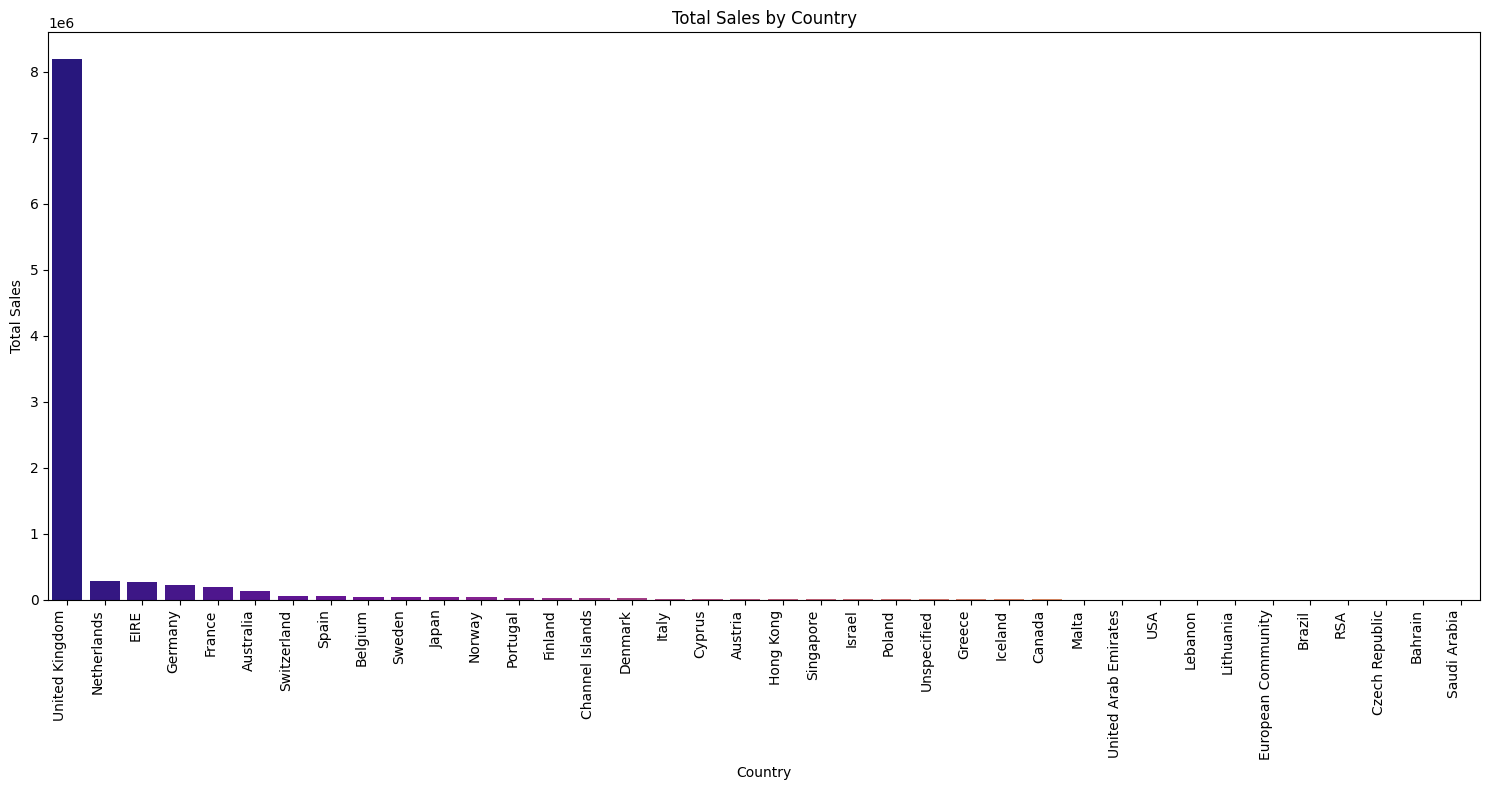

In [12]:
# Group by Country and sum the TotalPrice
country_sales = df.groupby('Country')['TotalPrice'].sum().reset_index()

# Sort the sales to find highest and lowest
country_sales_sorted = country_sales.sort_values(by='TotalPrice', ascending=False)

# Identify the country with the highest sales
highest_sales_country = country_sales_sorted.iloc[0]
# Identify the country with the lowest sales (excluding countries with 0 sales if any)
lowest_sales_country = country_sales_sorted[country_sales_sorted['TotalPrice'] > 0].iloc[-1]

print("Sales by Country (Top 5):")
display(country_sales_sorted.head())
print("\nSales by Country (Bottom 5, excluding zero sales):")
display(country_sales_sorted[country_sales_sorted['TotalPrice'] > 0].tail())

print(f"\nCountry with the Highest Sales: {highest_sales_country['Country']} with total sales of {highest_sales_country['TotalPrice']:.2f}")
print(f"Country with the Lowest Sales: {lowest_sales_country['Country']} with total sales of {lowest_sales_country['TotalPrice']:.2f}")

# Create the bar chart
plt.figure(figsize=(15, 8))
sns.barplot(x='Country', y='TotalPrice', data=country_sales_sorted, palette='plasma')
plt.title('Total Sales by Country')
plt.xlabel('Country')
plt.ylabel('Total Sales')
plt.xticks(rotation=90, ha='right') # Rotate country names for better readability
plt.tight_layout()
plt.show()

Monthly Sales for United Kingdom:


,Month,TotalPrice
0,2010-12,676742.620
1,2011-01,434308.300
2,2011-02,408247.910
3,2011-03,559707.390
4,2011-04,442254.041
5,2011-05,596459.860
6,2011-06,554478.350
7,2011-07,565479.841
8,2011-08,539130.500
9,2011-09,862018.152



Month with the Lowest Sales in United Kingdom: 2011-12 with total sales of 388735.43


/tmp/ipykernel_817/3337108537.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Month_str', y='TotalPrice', data=uk_monthly_sales, palette='magma')


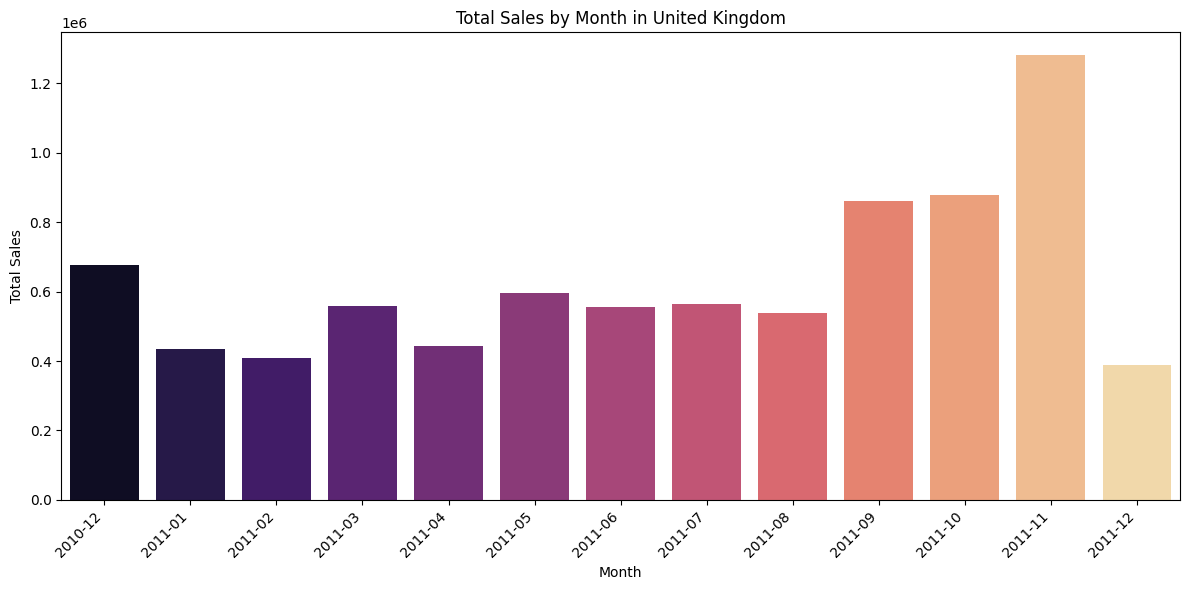

In [13]:
# Filter data for United Kingdom only
df_uk = df[df['Country'] == 'United Kingdom'].copy()

# Recalculate monthly sales for United Kingdom
uk_monthly_sales = df_uk.groupby('Month')['TotalPrice'].sum().reset_index()

# Find the month with the lowest sales in United Kingdom
lowest_uk_sales_month = uk_monthly_sales.loc[uk_monthly_sales['TotalPrice'].idxmin()]

print("Monthly Sales for United Kingdom:")
display(uk_monthly_sales)

print(f"\nMonth with the Lowest Sales in United Kingdom: {lowest_uk_sales_month['Month']} with total sales of {lowest_uk_sales_month['TotalPrice']:.2f}")

# Convert 'Month' to string for better plotting on x-axis
uk_monthly_sales['Month_str'] = uk_monthly_sales['Month'].astype(str)

plt.figure(figsize=(12, 6))
sns.barplot(x='Month_str', y='TotalPrice', data=uk_monthly_sales, palette='magma')
plt.title('Total Sales by Month in United Kingdom')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right') # Rotate month labels for better readability
plt.tight_layout()
plt.show()

Monthly Sales (Excluding United Kingdom):


,Month,TotalPrice
0,2010-12,72214.40
1,2011-01,125691.96
2,2011-02,89814.74
3,2011-03,123559.69
4,2011-04,50953.08
5,2011-05,126873.65
6,2011-06,136644.77
7,2011-07,115820.27
8,2011-08,143550.01
9,2011-09,157669.47



Month with the Lowest Sales (Excluding United Kingdom): 2011-12 with total sales of 44932.58


/tmp/ipykernel_817/1638220380.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Month_str', y='TotalPrice', data=exclude_uk_monthly_sales, palette='cividis')


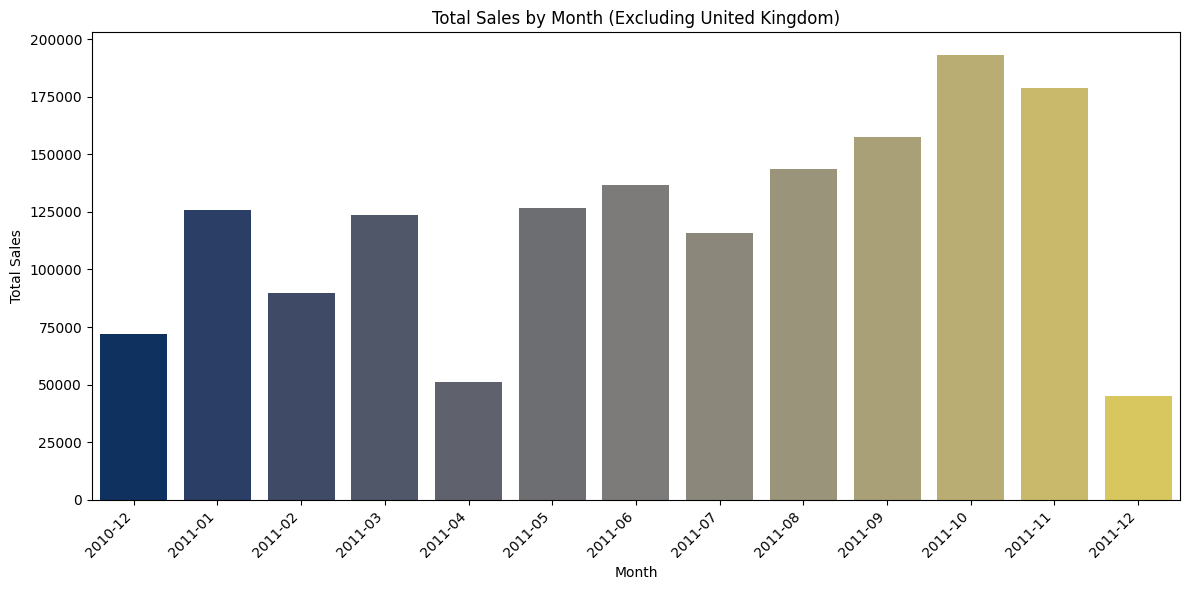

In [14]:
# Filter data to exclude United Kingdom
df_exclude_uk = df[df['Country'] != 'United Kingdom'].copy()

# Recalculate monthly sales for data excluding United Kingdom
exclude_uk_monthly_sales = df_exclude_uk.groupby('Month')['TotalPrice'].sum().reset_index()

# Find the month with the lowest sales (excluding United Kingdom)
lowest_exclude_uk_sales_month = exclude_uk_monthly_sales.loc[exclude_uk_monthly_sales['TotalPrice'].idxmin()]

print("Monthly Sales (Excluding United Kingdom):")
display(exclude_uk_monthly_sales)

print(f"\nMonth with the Lowest Sales (Excluding United Kingdom): {lowest_exclude_uk_sales_month['Month']} with total sales of {lowest_exclude_uk_sales_month['TotalPrice']:.2f}")

# Convert 'Month' to string for better plotting on x-axis
exclude_uk_monthly_sales['Month_str'] = exclude_uk_monthly_sales['Month'].astype(str)

plt.figure(figsize=(12, 6))
sns.barplot(x='Month_str', y='TotalPrice', data=exclude_uk_monthly_sales, palette='cividis')
plt.title('Total Sales by Month (Excluding United Kingdom)')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right') # Rotate month labels for better readability
plt.tight_layout()
plt.show()

In [15]:
# Count unique descriptions
num_unique_descriptions = df['Description'].nunique()
print(f"There are {num_unique_descriptions} unique product descriptions in the dataset.")

# Group by Description and sum TotalPrice to get sales for each product
product_sales = df.groupby('Description')['TotalPrice'].sum().reset_index()

# Sort in descending order for best-selling products
best_selling_products = product_sales.sort_values(by='TotalPrice', ascending=False)

# Display the top 5 best-selling products
print("\nTop 5 Best-Selling Products:")
display(best_selling_products.head(5))

# Sort in ascending order for least-selling products (excluding those with 0 or negative sales if any)
least_selling_products = product_sales[product_sales['TotalPrice'] > 0].sort_values(by='TotalPrice', ascending=True)

# Display the bottom 5 least-selling products
print("\nBottom 5 Least-Selling Products:")
display(least_selling_products.head(5))

There are 4223 unique product descriptions in the dataset.

Top 5 Best-Selling Products:


,Description,TotalPrice
1098,DOTCOM POSTAGE,206245.48
2915,REGENCY CAKESTAND 3 TIER,164762.19
3918,WHITE HANGING HEART T-LIGHT HOLDER,99668.47
2471,PARTY BUNTING,98302.98
1866,JUMBO BAG RED RETROSPOT,92356.03



Bottom 5 Least-Selling Products:


,Description,TotalPrice
2401,PADS TO MATCH ALL CUSHIONS,0.003
1729,HEN HOUSE W CHICK IN NEST,0.420
3126,SET 12 COLOURING PENCILS DOILEY,0.650
3897,WHITE BEADED GARLAND STRING 20LIGHT,0.800
3769,VINTAGE BLUE TINSEL REEL,0.840


In [17]:
# 1. Total Penjualan Setiap Bulan (already calculated as 'monthly_sales')

# 2. Jumlah Pelanggan aktif Setiap bulan nya
# Filter out rows with missing CustomerID before counting unique customers
active_customers_per_month = df[df['CustomerID'].notna()].groupby('Month')['CustomerID'].nunique().reset_index()
active_customers_per_month.rename(columns={'CustomerID': 'ActiveCustomers'}, inplace=True)

# 3. Jumlah Pesanan Setiap Bulan nya
orders_per_month = df.groupby('Month')['InvoiceNo'].nunique().reset_index()
orders_per_month.rename(columns={'InvoiceNo': 'TotalOrders'}, inplace=True)

# Merge all KPIs into one table
kpi_table = monthly_sales[['Month', 'TotalPrice']].copy()
kpi_table = kpi_table.merge(active_customers_per_month, on='Month', how='left')
kpi_table = kpi_table.merge(orders_per_month, on='Month', how='left')

# 4. Nilai Rata rata Per transaksi Per bulan nya juga
kpi_table['AverageTransactionValue'] = kpi_table['TotalPrice'] / kpi_table['TotalOrders']

# Fill NaN values (e.g., if a month had no sales, customers, or orders) with 0
kpi_table.fillna(0, inplace=True)

# Round 'TotalPrice' and 'AverageTransactionValue' columns
kpi_table['TotalPrice'] = kpi_table['TotalPrice'].round(2)
kpi_table['AverageTransactionValue'] = kpi_table['AverageTransactionValue'].round(2)

print("Monthly KPI Table:")
display(kpi_table)

Monthly KPI Table:


,Month,TotalPrice,ActiveCustomers,TotalOrders,AverageTransactionValue
0,2010-12,748957.02,948,2025,369.86
1,2011-01,560000.26,783,1476,379.40
2,2011-02,498062.65,798,1393,357.55
3,2011-03,683267.08,1020,1983,344.56
4,2011-04,493207.12,899,1744,282.80
5,2011-05,723333.51,1079,2162,334.57
6,2011-06,691123.12,1051,2012,343.50
7,2011-07,681300.11,993,1927,353.55
8,2011-08,682680.51,980,1737,393.02
9,2011-09,1019687.62,1302,2327,438.20


/tmp/ipykernel_817/1817240629.py:8: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(x='Month_str', y='TotalPrice', data=kpi_table, marker='o', palette='viridis')


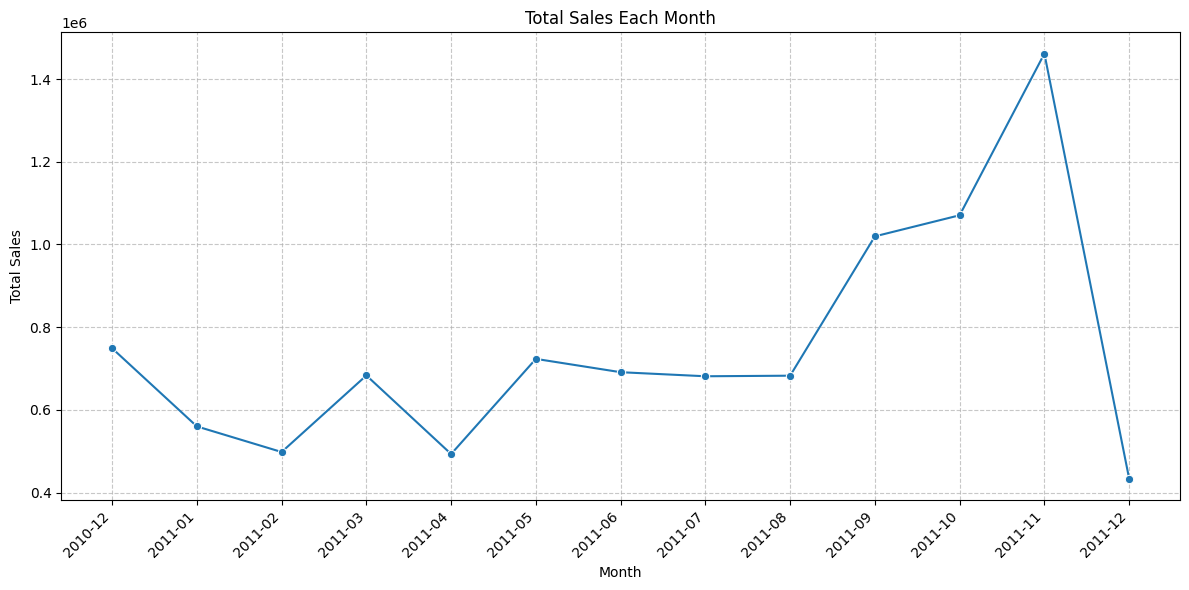

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

kpi_table['Month_str'] = kpi_table['Month'].astype(str)

# Plot Total Sales Each Month
plt.figure(figsize=(12, 6))
sns.lineplot(x='Month_str', y='TotalPrice', data=kpi_table, marker='o', palette='viridis')
plt.title('Total Sales Each Month')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

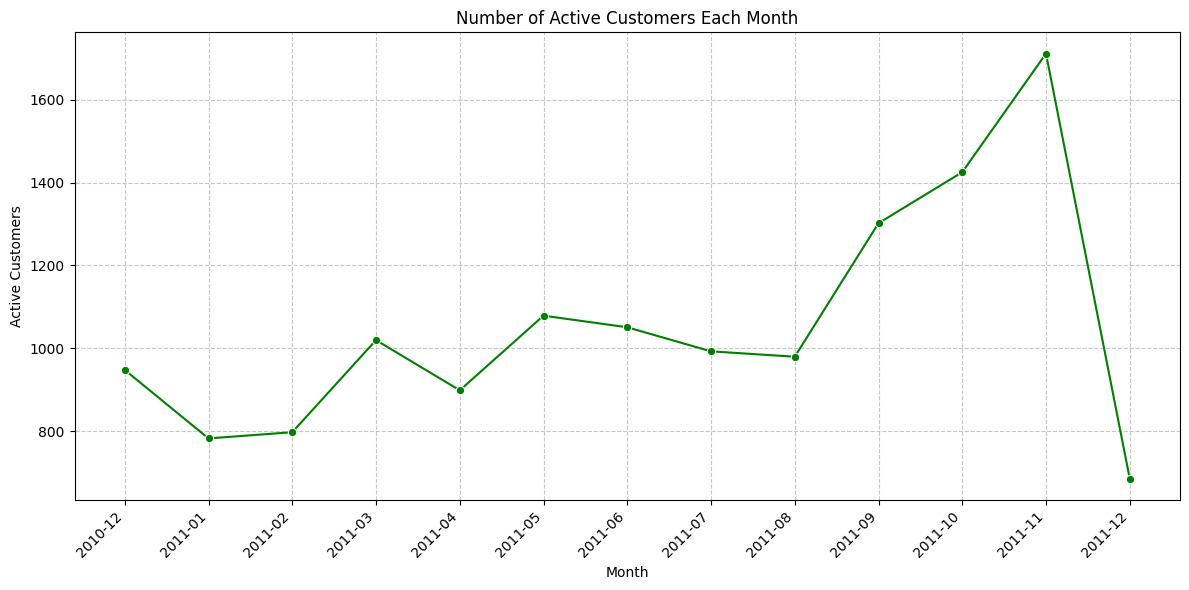

In [19]:
# Plot Number of Active Customers Each Month
plt.figure(figsize=(12, 6))
sns.lineplot(x='Month_str', y='ActiveCustomers', data=kpi_table, marker='o', color='green')
plt.title('Number of Active Customers Each Month')
plt.xlabel('Month')
plt.ylabel('Active Customers')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

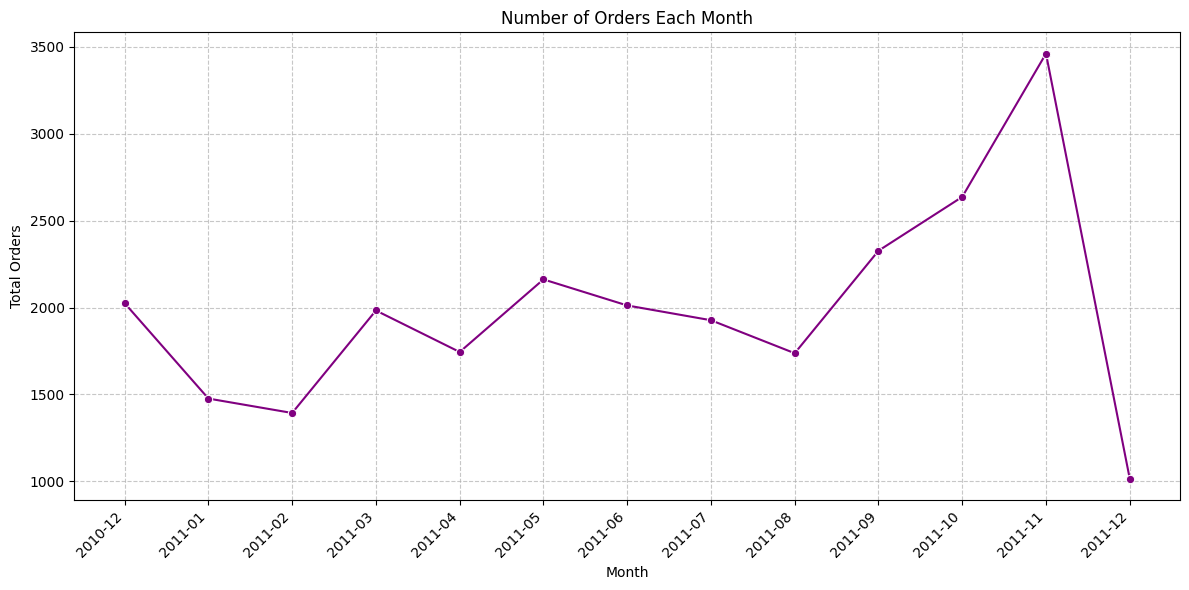

In [20]:
# Plot Number of Orders Each Month
plt.figure(figsize=(12, 6))
sns.lineplot(x='Month_str', y='TotalOrders', data=kpi_table, marker='o', color='purple')
plt.title('Number of Orders Each Month')
plt.xlabel('Month')
plt.ylabel('Total Orders')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

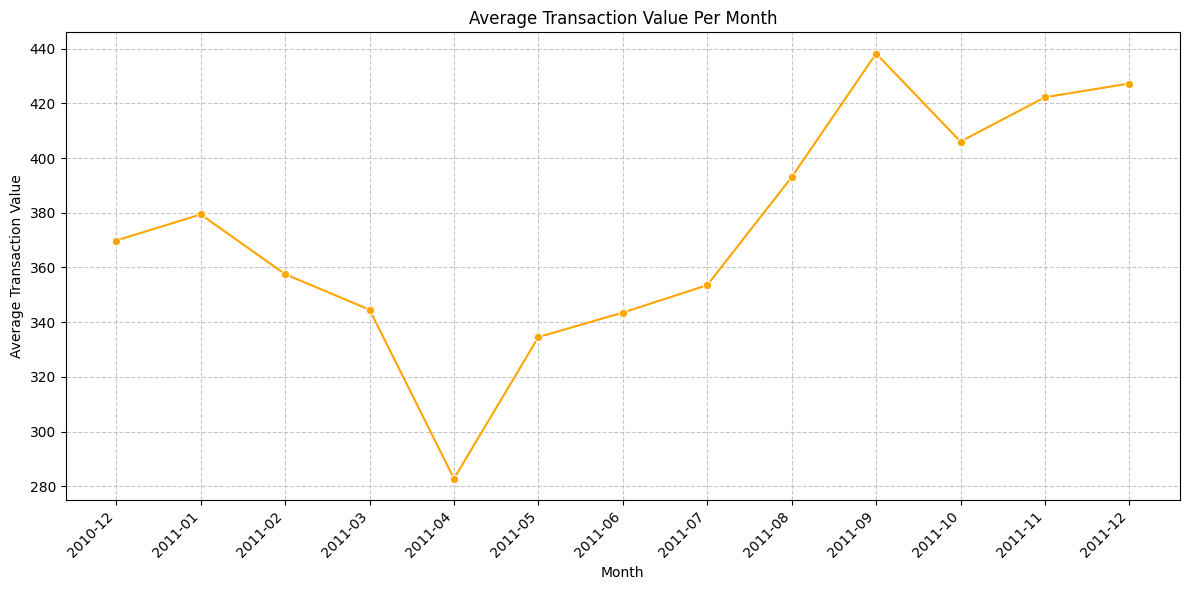

In [21]:
# Plot Average Transaction Value Per Month
plt.figure(figsize=(12, 6))
sns.lineplot(x='Month_str', y='AverageTransactionValue', data=kpi_table, marker='o', color='orange')
plt.title('Average Transaction Value Per Month')
plt.xlabel('Month')
plt.ylabel('Average Transaction Value')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Monthly KPI Table for United Kingdom

In [22]:
# Filter data for United Kingdom only
df_uk_kpi = df[df['Country'] == 'United Kingdom'].copy()

# 1. Total Sales Each Month for UK
uk_monthly_sales_kpi = df_uk_kpi.groupby('Month')['TotalPrice'].sum().reset_index()
uk_monthly_sales_kpi.rename(columns={'TotalPrice': 'TotalPrice'}, inplace=True)

# 2. Number of Active Customers Each Month for UK
uk_active_customers_per_month = df_uk_kpi[df_uk_kpi['CustomerID'].notna()].groupby('Month')['CustomerID'].nunique().reset_index()
uk_active_customers_per_month.rename(columns={'CustomerID': 'ActiveCustomers'}, inplace=True)

# 3. Number of Orders Each Month for UK
uk_orders_per_month = df_uk_kpi.groupby('Month')['InvoiceNo'].nunique().reset_index()
uk_orders_per_month.rename(columns={'InvoiceNo': 'TotalOrders'}, inplace=True)

# Merge all UK KPIs into one table
uk_kpi_table = uk_monthly_sales_kpi.copy()
uk_kpi_table = uk_kpi_table.merge(uk_active_customers_per_month, on='Month', how='left')
uk_kpi_table = uk_kpi_table.merge(uk_orders_per_month, on='Month', how='left')

# 4. Average Transaction Value Per Month for UK
uk_kpi_table['AverageTransactionValue'] = uk_kpi_table['TotalPrice'] / uk_kpi_table['TotalOrders']

# Fill NaN values (e.g., if a month had no sales, customers, or orders) with 0
uk_kpi_table.fillna(0, inplace=True)

# Round 'TotalPrice' and 'AverageTransactionValue' columns
uk_kpi_table['TotalPrice'] = uk_kpi_table['TotalPrice'].round(2)
uk_kpi_table['AverageTransactionValue'] = uk_kpi_table['AverageTransactionValue'].round(2)

print("Monthly KPI Table for United Kingdom:")
display(uk_kpi_table)

Monthly KPI Table for United Kingdom:


,Month,TotalPrice,ActiveCustomers,TotalOrders,AverageTransactionValue
0,2010-12,676742.62,871,1885,359.01
1,2011-01,434308.30,684,1327,327.29
2,2011-02,408247.91,714,1259,324.26
3,2011-03,559707.39,923,1802,310.60
4,2011-04,442254.04,817,1622,272.66
5,2011-05,596459.86,985,1973,302.31
6,2011-06,554478.35,943,1830,302.99
7,2011-07,565479.84,899,1764,320.57
8,2011-08,539130.50,867,1546,348.73
9,2011-09,862018.15,1177,2090,412.45


### Monthly KPI Table Excluding United Kingdom

In [23]:
# Filter data to exclude United Kingdom
df_exclude_uk_kpi = df[df['Country'] != 'United Kingdom'].copy()

# 1. Total Sales Each Month (Excluding UK)
exclude_uk_monthly_sales_kpi = df_exclude_uk_kpi.groupby('Month')['TotalPrice'].sum().reset_index()
exclude_uk_monthly_sales_kpi.rename(columns={'TotalPrice': 'TotalPrice'}, inplace=True)

# 2. Number of Active Customers Each Month (Excluding UK)
exclude_uk_active_customers_per_month = df_exclude_uk_kpi[df_exclude_uk_kpi['CustomerID'].notna()].groupby('Month')['CustomerID'].nunique().reset_index()
exclude_uk_active_customers_per_month.rename(columns={'CustomerID': 'ActiveCustomers'}, inplace=True)

# 3. Number of Orders Each Month (Excluding UK)
exclude_uk_orders_per_month = df_exclude_uk_kpi.groupby('Month')['InvoiceNo'].nunique().reset_index()
exclude_uk_orders_per_month.rename(columns={'InvoiceNo': 'TotalOrders'}, inplace=True)

# Merge all Exclude UK KPIs into one table
exclude_uk_kpi_table = exclude_uk_monthly_sales_kpi.copy()
exclude_uk_kpi_table = exclude_uk_kpi_table.merge(exclude_uk_active_customers_per_month, on='Month', how='left')
exclude_uk_kpi_table = exclude_uk_kpi_table.merge(exclude_uk_orders_per_month, on='Month', how='left')

# 4. Average Transaction Value Per Month (Excluding UK)
exclude_uk_kpi_table['AverageTransactionValue'] = exclude_uk_kpi_table['TotalPrice'] / exclude_uk_kpi_table['TotalOrders']

# Fill NaN values (e.g., if a month had no sales, customers, or orders) with 0
exclude_uk_kpi_table.fillna(0, inplace=True)

# Round 'TotalPrice' and 'AverageTransactionValue' columns
exclude_uk_kpi_table['TotalPrice'] = exclude_uk_kpi_table['TotalPrice'].round(2)
exclude_uk_kpi_table['AverageTransactionValue'] = exclude_uk_kpi_table['AverageTransactionValue'].round(2)

print("Monthly KPI Table Excluding United Kingdom:")
display(exclude_uk_kpi_table)

Monthly KPI Table Excluding United Kingdom:


,Month,TotalPrice,ActiveCustomers,TotalOrders,AverageTransactionValue
0,2010-12,72214.40,77,140,515.82
1,2011-01,125691.96,99,149,843.57
2,2011-02,89814.74,84,134,670.26
3,2011-03,123559.69,97,181,682.65
4,2011-04,50953.08,82,122,417.65
5,2011-05,126873.65,94,189,671.29
6,2011-06,136644.77,108,182,750.80
7,2011-07,115820.27,94,163,710.55
8,2011-08,143550.01,113,191,751.57
9,2011-09,157669.47,125,237,665.27


### Monthly KPI Difference: United Kingdom vs. Exclude United Kingdom

In [24]:
# Merge the UK and Exclude UK KPI tables on 'Month'
kpi_difference_table = uk_kpi_table.merge(
    exclude_uk_kpi_table,
    on='Month',
    how='outer',
    suffixes=('_UK', '_ExcludeUK')
)

# Fill any NaN values that might arise if a month exists in one table but not the other
kpi_difference_table.fillna(0, inplace=True)

# Calculate the difference for each KPI
kpi_difference_table['TotalPrice_Difference'] = kpi_difference_table['TotalPrice_UK'] - kpi_difference_table['TotalPrice_ExcludeUK']
kpi_difference_table['ActiveCustomers_Difference'] = kpi_difference_table['ActiveCustomers_UK'] - kpi_difference_table['ActiveCustomers_ExcludeUK']
kpi_difference_table['TotalOrders_Difference'] = kpi_difference_table['TotalOrders_UK'] - kpi_difference_table['TotalOrders_ExcludeUK']
kpi_difference_table['AverageTransactionValue_Difference'] = kpi_difference_table['AverageTransactionValue_UK'] - kpi_difference_table['AverageTransactionValue_ExcludeUK']

# Select and display the relevant columns
final_difference_kpi = kpi_difference_table[[
    'Month',
    'TotalPrice_UK',
    'TotalPrice_ExcludeUK',
    'TotalPrice_Difference',
    'ActiveCustomers_UK',
    'ActiveCustomers_ExcludeUK',
    'ActiveCustomers_Difference',
    'TotalOrders_UK',
    'TotalOrders_ExcludeUK',
    'TotalOrders_Difference',
    'AverageTransactionValue_UK',
    'AverageTransactionValue_ExcludeUK',
    'AverageTransactionValue_Difference'
]].copy()

# Round difference columns for consistency
final_difference_kpi['TotalPrice_Difference'] = final_difference_kpi['TotalPrice_Difference'].round(2)
final_difference_kpi['AverageTransactionValue_Difference'] = final_difference_kpi['AverageTransactionValue_Difference'].round(2)

print("Monthly KPI Difference (United Kingdom vs. Exclude United Kingdom):")
display(final_difference_kpi)

Monthly KPI Difference (United Kingdom vs. Exclude United Kingdom):


,Month,TotalPrice_UK,TotalPrice_ExcludeUK,TotalPrice_Difference,ActiveCustomers_UK,ActiveCustomers_ExcludeUK,ActiveCustomers_Difference,TotalOrders_UK,TotalOrders_ExcludeUK,TotalOrders_Difference,AverageTransactionValue_UK,AverageTransactionValue_ExcludeUK,AverageTransactionValue_Difference
0,2010-12,676742.62,72214.40,604528.22,871,77,794,1885,140,1745,359.01,515.82,-156.81
1,2011-01,434308.30,125691.96,308616.34,684,99,585,1327,149,1178,327.29,843.57,-516.28
2,2011-02,408247.91,89814.74,318433.17,714,84,630,1259,134,1125,324.26,670.26,-346.00
3,2011-03,559707.39,123559.69,436147.70,923,97,826,1802,181,1621,310.60,682.65,-372.05
4,2011-04,442254.04,50953.08,391300.96,817,82,735,1622,122,1500,272.66,417.65,-144.99
5,2011-05,596459.86,126873.65,469586.21,985,94,891,1973,189,1784,302.31,671.29,-368.98
6,2011-06,554478.35,136644.77,417833.58,943,108,835,1830,182,1648,302.99,750.80,-447.81
7,2011-07,565479.84,115820.27,449659.57,899,94,805,1764,163,1601,320.57,710.55,-389.98
8,2011-08,539130.50,143550.01,395580.49,867,113,754,1546,191,1355,348.73,751.57,-402.84
9,2011-09,862018.15,157669.47,704348.68,1177,125,1052,2090,237,1853,412.45,665.27,-252.82


In [25]:
# Get sales for December 2011
december_2011_sales = monthly_sales[monthly_sales['Month'] == '2011-12']['TotalPrice'].iloc[0]

# Calculate average sales for months before December 2011
sales_before_dec_2011 = monthly_sales[monthly_sales['Month'] < '2011-12']
average_sales_before_dec_2011 = sales_before_dec_2011['TotalPrice'].mean()

# Calculate percentage decrease
percentage_decrease = ((average_sales_before_dec_2011 - december_2011_sales) / average_sales_before_dec_2011) * 100

print(f"Total Sales in December 2011: {december_2011_sales:.2f}")
print(f"Average Sales in months before December 2011: {average_sales_before_dec_2011:.2f}")
print(f"Percentage Decrease in December 2011 sales compared to average of previous months: {percentage_decrease:.2f}%")

Total Sales in December 2011: 433668.01
Average Sales in months before December 2011: 776173.33
Percentage Decrease in December 2011 sales compared to average of previous months: 44.13%
